# **Earthquake Risk Prediction — Pipeline**

This notebook walks through the full ML pipeline:
1. Imports & Setup
2. Load & Analyze Raw Data
3. Preprocessing
4. Handle Class Imbalance with SMOTE
5. Train & Compare Models
6. Hyperparameter Optimization
7. Model Evaluation
8. Predictions

**Target:** Classify earthquake risk as `low`, `medium`, or `high` based on seismic features.

## 1. Imports & Setup

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import warnings
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, precision_recall_curve
)

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

PROJECT_ROOT = Path().resolve().parent
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'earthquake_data.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
VIS_DIR = PROJECT_ROOT / 'outputs' / 'visualizations'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')
print(f'Project root: {PROJECT_ROOT}')

Setup complete.
Project root: /Users/bishalnarzary/Earthquake-Risk-Prediction


## 2. Load & Analyze Raw Data

In [2]:
df = pd.read_csv(RAW_DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (20000, 22)


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2010-01-03T11:43:25.930Z,44.021,148.455,27.7,4.3,mb,24.0,137.6,NaN,1.19,...,2014-11-07T01:40:23.917Z,"141 km E of Shikotan, Russia",earthquake,NaN,20.7,NaN,6.0,reviewed,us,us
1,2010-01-05T19:33:47.760Z,30.087,131.018,37.9,4.3,mb,35.0,128.5,NaN,1.05,...,2014-11-07T01:40:25.381Z,"48 km SE of Koseda, Japan",earthquake,NaN,8.6,NaN,13.0,reviewed,us,us
2,2010-01-06T20:39:40.130Z,42.017,142.291,70.2,4.3,mwr,97.0,90.7,NaN,0.71,...,2014-11-07T01:40:25.573Z,"35 km S of Shizunai-furukawach?, Japan",earthquake,NaN,NaN,NaN,NaN,reviewed,us,nied
3,2010-01-07T01:36:07.380Z,36.294,141.775,37.5,4.4,mwr,38.0,127.0,NaN,0.74,...,2014-11-07T01:40:25.590Z,"105 km NE of Hasaki, Japan",earthquake,NaN,6.6,NaN,NaN,reviewed,us,nied
4,2010-01-07T13:24:11.130Z,36.235,141.746,37.6,4.2,mwr,42.0,119.1,NaN,1.10,...,2014-11-07T01:40:25.673Z,"99 km NE of Hasaki, Japan",earthquake,NaN,10.2,NaN,NaN,reviewed,us,nied


In [3]:
print('Data types:')
print(df.dtypes)
print(f'\nMissing values:')
print(df.isnull().sum())

Data types:
time                object
latitude           float64
longitude          float64
depth              float64
mag                float64
magType             object
nst                float64
gap                float64
dmin               float64
rms                float64
net                 object
id                  object
updated             object
place               object
type                object
horizontalError    float64
depthError         float64
magError           float64
magNst             float64
status              object
locationSource      object
magSource           object
dtype: object

Missing values:
time                  0
latitude              0
longitude             0
depth                 0
mag                   0
magType               0
nst                7695
gap                   4
dmin               8463
rms                   1
net                   0
id                    0
updated               0
place                 0
type                  0
hor

In [4]:
df[['latitude', 'longitude', 'depth', 'mag']].describe()

,latitude,longitude,depth,mag
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,36.053624,138.196420,59.623995,4.556080
std,6.113209,13.151994,87.428810,0.396112
min,4.173000,67.554000,0.000000,2.700000
25%,33.346825,140.142425,16.497500,4.300000
50%,36.976000,141.865450,35.000000,4.500000
75%,39.063500,143.023025,55.848750,4.700000
max,56.800900,149.236600,644.879000,9.100000


### **Distribution of Key Features**

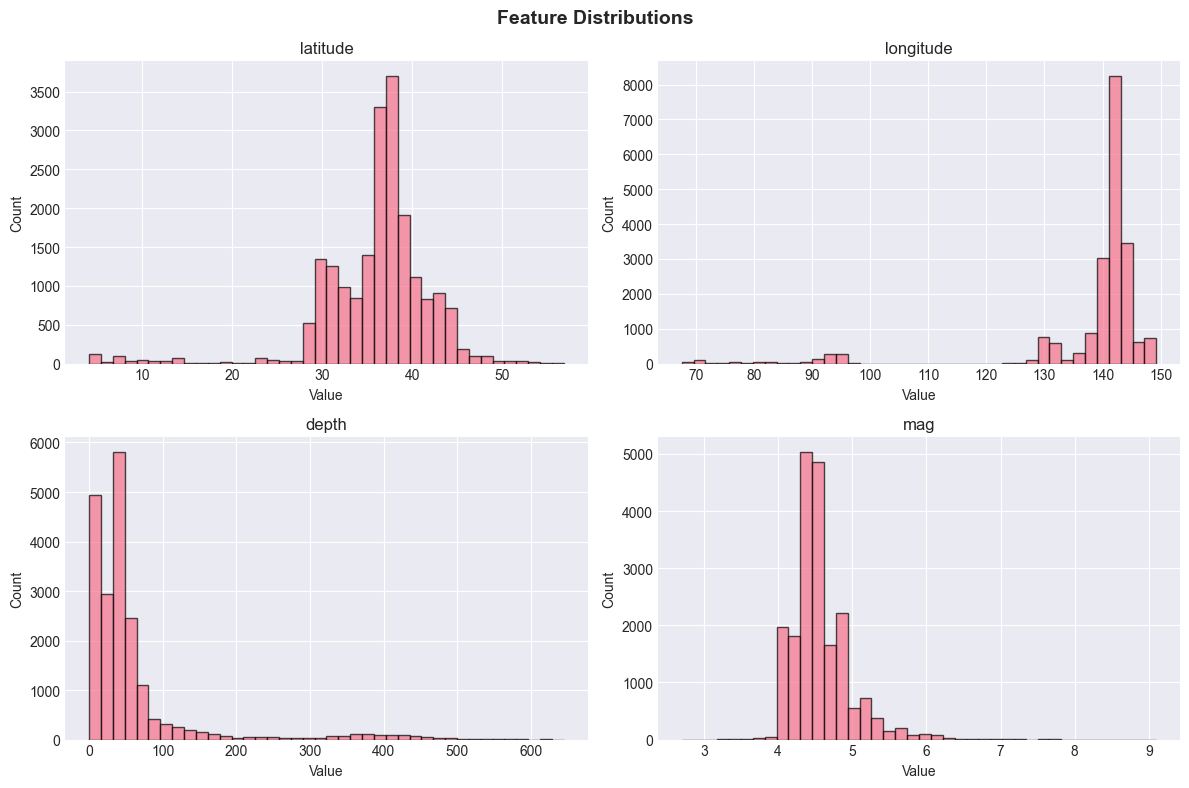

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), ['latitude', 'longitude', 'depth', 'mag']):
    ax.hist(df[col].dropna(), bins=40, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### **Correlation Heatmap**

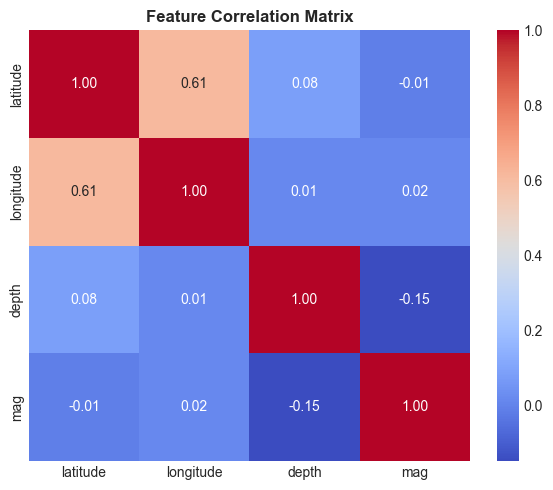

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    df[['latitude', 'longitude', 'depth', 'mag']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [7]:
def remove_outliers(df):
    cols = ['latitude', 'longitude', 'depth', 'mag']
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)
    print(f'  Rows before outlier removal: {len(df)}')
    df = df[mask]
    print(f'  Rows after outlier removal:  {len(df)}')
    return df

def feature_engineering(df):
    df = df.copy()
    df['geo_distance'] = np.sqrt(df['latitude']**2 + df['longitude']**2)
    return df

def categorize_risk(df):
    df = df.copy()
    df['risk'] = pd.qcut(df['mag'], q=3, labels=['low', 'medium', 'high'])
    return df

data = df[['latitude', 'longitude', 'depth', 'mag']].dropna().copy()
data = remove_outliers(data)
data = feature_engineering(data)
data = categorize_risk(data)

print(f'\nFinal dataset shape: {data.shape}')
print('\nRisk class distribution:')
print(data['risk'].value_counts().sort_index())
data.head()

  Rows before outlier removal: 20000
  Rows after outlier removal:  14190

Final dataset shape: (14190, 6)

Risk class distribution:
risk
low       6135
medium    3834
high      4221
Name: count, dtype: int64


,latitude,longitude,depth,mag,geo_distance,risk
2,42.017,142.291,70.2,4.3,148.364945,low
3,36.294,141.775,37.5,4.4,146.346866,low
4,36.235,141.746,37.6,4.2,146.304148,low
5,29.167,142.235,23.4,4.3,145.194728,low
6,43.014,145.272,101.4,3.8,151.506297,low


### **Visualize Risk Class Distribution**

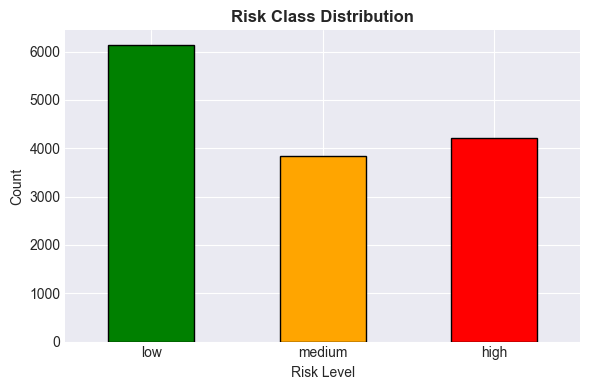

In [8]:
plt.figure(figsize=(6, 4))
data['risk'].value_counts().sort_index().plot(kind='bar', color=['green', 'orange', 'red'], edgecolor='black')
plt.title('Risk Class Distribution', fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **Scale Features and Encode Labels**

In [9]:
FEATURE_COLS = ['latitude', 'longitude', 'depth', 'geo_distance']

X = data[FEATURE_COLS].values
y_raw = data['risk'].values

scaler = StandardScaler()
label_encoder = LabelEncoder()

X_scaled = scaler.fit_transform(X)
y = label_encoder.fit_transform(y_raw)

print('Risk label mapping:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

pd.DataFrame(X_train, columns=FEATURE_COLS).to_csv(PROCESSED_DIR / 'X_train.csv', index=False)
pd.DataFrame(X_test, columns=FEATURE_COLS).to_csv(PROCESSED_DIR / 'X_test.csv', index=False)
pd.DataFrame(y_train, columns=['risk']).to_csv(PROCESSED_DIR / 'y_train.csv', index=False)
pd.DataFrame(y_test, columns=['risk']).to_csv(PROCESSED_DIR / 'y_test.csv', index=False)
print('\nProcessed data saved.')

Risk label mapping: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

Training samples: 11352
Testing samples:  2838

Processed data saved.


## 4. Handle Class Imbalance with SMOTE

In [10]:
print('Class distribution before SMOTE:')
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(label_encoder.classes_, counts):
    print(f'  {cls}: {cnt}')

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nClass distribution after SMOTE:')
unique, counts = np.unique(y_train_bal, return_counts=True)
for cls, cnt in zip(label_encoder.classes_, counts):
    print(f'  {cls}: {cnt}')

print(f'\nTotal training samples after SMOTE: {len(X_train_bal)}')

Class distribution before SMOTE:
  high: 3377
  low: 4908
  medium: 3067

Class distribution after SMOTE:
  high: 4908
  low: 4908
  medium: 4908

Total training samples after SMOTE: 14724


## 5. Train & Compare Models

In [11]:
import time

models = {
    'Random Forest':      RandomForestClassifier(random_state=42),
    'Gradient Boosting':  GradientBoostingClassifier(random_state=42),
    'XGBoost':            XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM':                SVC(random_state=42, probability=True),
    'Logistic Regression':LogisticRegression(random_state=42, max_iter=1000)
}

results = {}

for name, model in models.items():
    print(f'Training {name}...')
    t0 = time.time()
    model.fit(X_train_bal, y_train_bal)
    elapsed = time.time() - t0
    cv = cross_val_score(model, X_train_bal, y_train_bal, cv=5, scoring='f1_weighted')
    results[name] = {'model': model, 'cv_mean': cv.mean(), 'cv_std': cv.std(), 'time': elapsed}
    print(f'  CV F1: {cv.mean():.4f} (±{cv.std():.4f})  |  Time: {elapsed:.2f}s')

print('\nAll models trained.')

Training Random Forest...
  CV F1: 0.5422 (±0.0708)  |  Time: 2.44s
Training Gradient Boosting...
  CV F1: 0.4124 (±0.0141)  |  Time: 4.45s
Training XGBoost...
  CV F1: 0.4769 (±0.0417)  |  Time: 0.39s
Training SVM...
  CV F1: 0.3804 (±0.0056)  |  Time: 24.55s
Training Logistic Regression...
  CV F1: 0.3712 (±0.0118)  |  Time: 0.04s

All models trained.


In [12]:
comparison = pd.DataFrame([
    {'Model': n, 'CV F1-Score': f"{r['cv_mean']:.4f}", 'CV Std': f"{r['cv_std']:.4f}", 'Time (s)': f"{r['time']:.2f}"}
    for n, r in results.items()
]).sort_values('CV F1-Score', ascending=False).reset_index(drop=True)

print('Model Comparison (sorted by CV F1-Score):')
comparison

Model Comparison (sorted by CV F1-Score):


,Model,CV F1-Score,CV Std,Time (s)
0,Random Forest,0.5422,0.0708,2.44
1,XGBoost,0.4769,0.0417,0.39
2,Gradient Boosting,0.4124,0.0141,4.45
3,SVM,0.3804,0.0056,24.55
4,Logistic Regression,0.3712,0.0118,0.04


### **Select Best Model**

In [13]:
best_name = max(results, key=lambda n: results[n]['cv_mean'])
best_model = results[best_name]['model']
print(f'Best model: {best_name} (CV F1: {results[best_name]["cv_mean"]:.4f})')

Best model: Random Forest (CV F1: 0.5422)


## 6. Hyperparameter Optimization

In [14]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print(f'Running GridSearchCV on {best_name}...')
print(f'Parameter combinations: {np.prod([len(v) for v in param_grid.values()])}')

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_bal, y_train_bal)

best_model = grid_search.best_estimator_
print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV F1: {grid_search.best_score_:.4f}')

Running GridSearchCV on Random Forest...
Parameter combinations: 108

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1: 0.5443


### **Saving Model and Processor**

In [26]:
sys.path.insert(0, str(Path().resolve().parent))
from src.data_preprocessing import EarthquakePreprocessor

In [ ]:
preprocessor = EarthquakePreprocessor()
preprocessor.fit(df)

joblib.dump(best_model, MODEL_DIR / 'model.pkl')
joblib.dump(preprocessor, MODEL_DIR / 'preprocessor.pkl')
print('Model and preprocessor saved.')

ModuleNotFoundError: No module named 'src'

## 7. Model Evaluation

In [18]:
labels = label_encoder.classes_

y_pred = best_model.predict(X_test)

metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted'),
    'Recall':    recall_score(y_test, y_pred, average='weighted'),
    'F1-Score':  f1_score(y_test, y_pred, average='weighted')
}

print('Overall Performance:')
for k, v in metrics.items():
    print(f'  {k:<12}: {v:.4f} ({v*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=labels))

Overall Performance:
  Accuracy    : 0.3855 (38.55%)
  Precision   : 0.3874 (38.74%)
  Recall      : 0.3855 (38.55%)
  F1-Score    : 0.3862 (38.62%)

Classification Report:
              precision    recall  f1-score   support

        high       0.36      0.38      0.37       844
         low       0.47      0.45      0.46      1227
      medium       0.28      0.28      0.28       767

    accuracy                           0.39      2838
   macro avg       0.37      0.37      0.37      2838
weighted avg       0.39      0.39      0.39      2838



### **Confusion Matrix**

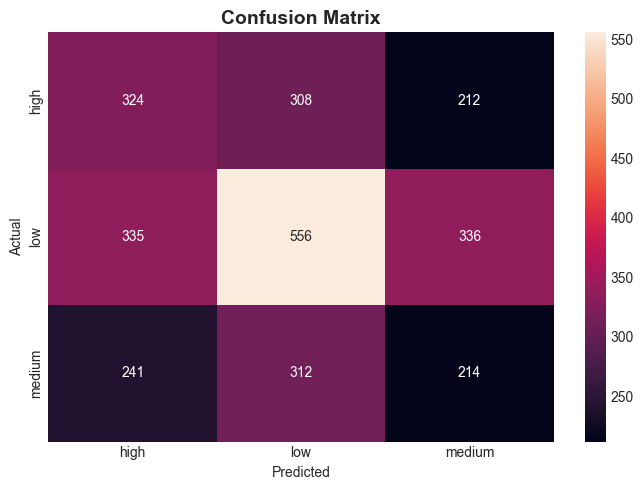

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(VIS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### **Feature Importance**

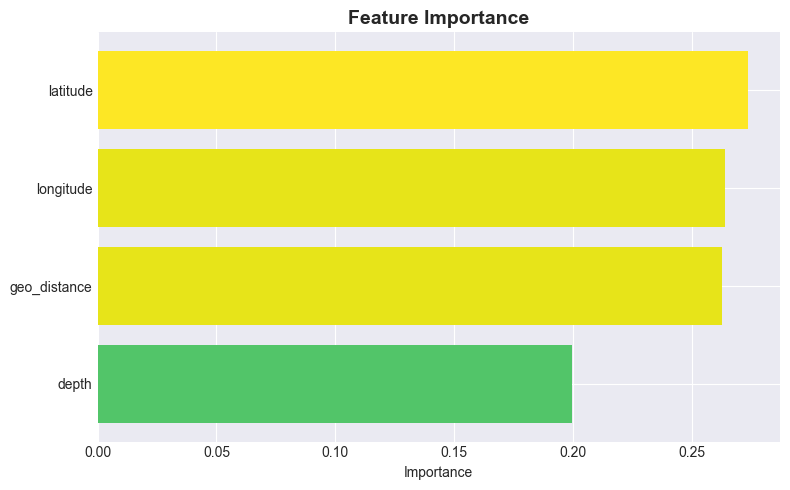

In [20]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

viridis = plt.colormaps.get_cmap('viridis')
colors = viridis(importances[indices] / importances[indices].max())

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], color=colors)
plt.yticks(range(len(indices)), [FEATURE_COLS[i] for i in indices])
plt.gca().invert_yaxis()
plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(VIS_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### **Precision-Recall Curve**

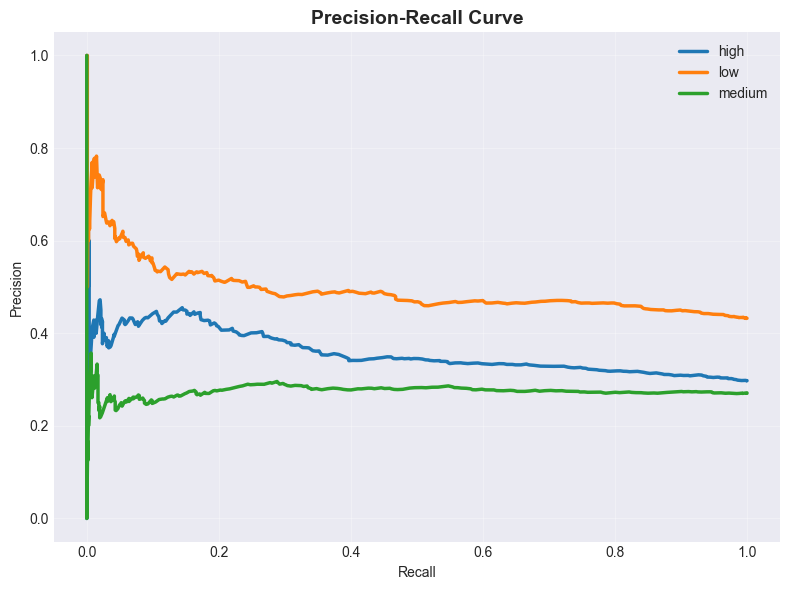

In [21]:
y_score = best_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=range(len(labels)))

colors_pr = ['#1f77b4', '#ff7f0e', '#2ca02c']
plt.figure(figsize=(8, 6))
for i, label in enumerate(labels):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=label, linewidth=2.5, color=colors_pr[i])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VIS_DIR / 'precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

### **Cross-Validation on Test Set**

In [22]:
cv_scores = cross_val_score(best_model, X_train_bal, y_train_bal, cv=5, scoring='f1_weighted')
print('Cross-Validation (F1-weighted):')
print(f'  Scores: {cv_scores}')
print(f'  Mean:   {cv_scores.mean():.4f}')
print(f'  Std:    {cv_scores.std():.4f}')

Cross-Validation (F1-weighted):
  Scores: [0.49539608 0.48999654 0.47750537 0.5976673  0.6607101 ]
  Mean:   0.5443
  Std:    0.0724


## 8. Predictions

In [23]:
def predict_single(features: dict):
    df_input = pd.DataFrame([features])
    df_input['geo_distance'] = np.sqrt(df_input['latitude']**2 + df_input['longitude']**2)
    X_input = scaler.transform(df_input[FEATURE_COLS])
    pred = best_model.predict(X_input)[0]
    probs = best_model.predict_proba(X_input)[0]
    risk_level = label_encoder.classes_[pred]
    prob_dict = dict(zip(label_encoder.classes_, probs))
    return risk_level, prob_dict

examples = [
    ('Low-Risk',    {'latitude': 34.05, 'longitude': -118.25, 'depth': 5.0,  'mag': 3.2}),
    ('Medium-Risk', {'latitude': 35.68, 'longitude':  139.65, 'depth': 35.0, 'mag': 5.5}),
    ('High-Risk',   {'latitude': 38.30, 'longitude':  142.37, 'depth': 60.0, 'mag': 7.8}),
]

for label, features in examples:
    risk, probs = predict_single(features)
    print(f'{label} Example → Predicted: {risk.upper()}')
    for cls, p in sorted(probs.items(), key=lambda x: x[1], reverse=True):
        print(f'  {cls:<10}: {p:.2%}')
    print()

Low-Risk Example → Predicted: HIGH
  high      : 46.33%
  low       : 45.67%
  medium    : 8.00%

Medium-Risk Example → Predicted: LOW
  low       : 62.33%
  medium    : 26.33%
  high      : 11.33%

High-Risk Example → Predicted: LOW
  low       : 40.33%
  medium    : 33.00%
  high      : 26.67%



### **Batch Prediction from CSV**

In [24]:
TEST_CSV = PROJECT_ROOT / 'data' / 'raw' / 'test_data_1000.csv'

if TEST_CSV.exists():
    test_df = pd.read_csv(TEST_CSV)
    test_df['geo_distance'] = np.sqrt(test_df['latitude']**2 + test_df['longitude']**2)
    X_batch = scaler.transform(test_df[FEATURE_COLS])
    preds = best_model.predict(X_batch)
    probs = best_model.predict_proba(X_batch)
    test_df['predicted_risk'] = label_encoder.inverse_transform(preds)
    test_df['confidence'] = probs.max(axis=1)

    output_path = PROJECT_ROOT / 'outputs' / 'predictions' / 'results.csv'
    output_path.parent.mkdir(parents=True, exist_ok=True)
    test_df.to_csv(output_path, index=False)

    print(f'Predictions saved to: {output_path}')
    print(f'\nPrediction distribution:')
    print(test_df['predicted_risk'].value_counts())
    test_df[['latitude', 'longitude', 'depth', 'mag', 'predicted_risk', 'confidence']].head(10)
else:
    print(f'Test CSV not found at {TEST_CSV}. Skipping batch prediction.')

Test CSV not found at /Users/bishalnarzary/Earthquake-Risk-Prediction/data/raw/test_data_1000.csv. Skipping batch prediction.


## Summary

| Step | Details |
|------|---------|
| Dataset | USGS Earthquake Data |
| Features | `latitude`, `longitude`, `depth`, `geo_distance` |
| Target | `risk` — low / medium / high |
| Best Model | Random Forest (optimized via GridSearchCV) |
| Class Balancing | SMOTE |
| Evaluation | F1-weighted, Confusion Matrix, Precision-Recall Curve |